# Projeto 2

* Bibliotecas necessárias

In [1]:
import moviepy.editor as mpe
from moviepy.editor import *
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd

Video original utilizado

In [2]:
video_original = mpe.VideoFileClip("Jotaro.mp4")

Teste do video original

In [ ]:
video_original.ipython_display(width=480, maxduration = 142)

Áudio original

In [3]:
audio_shrek = mpe.AudioFileClip("Audio_Shrek.wav")


Teste do áudio

audio_shrek.ipython_display(maxduration = 142)

Colocando o audio no video

In [4]:
video_modf = video_original.set_audio(audio_shrek)
video_modf.write_videofile('Video_inicial.mp4')

Moviepy - Building video Video_inicial.mp4.
MoviePy - Writing audio in Video_inicialTEMP_MPY_wvf_snd.mp3


MoviePy - Done.
Moviepy - Writing video Video_inicial.mp4



Moviepy - Done !
Moviepy - video ready Video_inicial.mp4


Teste do video com novo audio

In [ ]:
video_modf.ipython_display(width=480, maxduration = 142)

Invertendo o eixo do video a cada 20s

In [ ]:
# Função que espelha o vídeo a cada 20 segundos
def flip_every_20s(get_frame, t):
    frame = get_frame(t)
    invertido = int(t / 20) % 2 == 1  # alterna a cada 20 segundos
    if invertido:
        return frame[:, ::-1]  # espelhamento horizontal
    else:
        return frame
    
video_modf_inv = video_modf.fl(flip_every_20s)

Teste do video invertendo

In [ ]:
video_modf_inv.ipython_display(width=480, maxduration = 142)

Diminuindo o som gradativamente

In [ ]:
duration = video_modf_inv.duration
audio_video = video_modf_inv.audio

def decrease(t):
    if np.isscalar(t):
        frame = audio_video.get_frame(t)
        if t >= duration - 10:
            volume = 0.0
        else:
            step = int(t // 30)
            volume = max(1.0 - 0.2 * step, 0.0)
        return frame * volume
    else:
        return np.array([decrease(ti) for ti in t])


new_audio = AudioClip(make_frame=decrease, duration=duration, fps=44100)

video_modf_inv_dim = video_modf_inv.set_audio(new_audio)

Teste do video com audio diminuindo

In [ ]:
video_modf_inv_dim.ipython_display(width=480, maxduration=142)

Teste para verificar se o volume está sendo diminuido corretamente

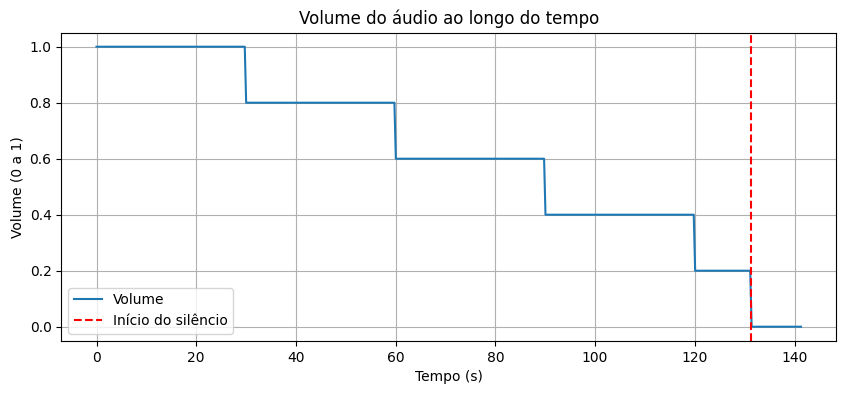

In [18]:
times_for_plot = np.linspace(0, duration, 500)
volumes = []

for t in times_for_plot:
    if t >= duration - 10:
        v = 0.0
    else:
        step = int(t // 30)
        v = max(1.0 - 0.2 * step, 0.0)
    volumes.append(v)

plt.figure(figsize=(10,4))
plt.plot(times_for_plot, volumes, label="Volume")
plt.axvline(duration - 10, color='red', linestyle='--', label='Início do silêncio')
plt.xlabel("Tempo (s)")
plt.ylabel("Volume (0 a 1)")
plt.title("Volume do áudio ao longo do tempo")
plt.legend()
plt.grid(True)
plt.show()

Realizando os cortes no vídeo e remontando ele

In [ ]:
part_1 = video_modf_inv_dim.subclip(0, 60) # trecho de 0 a 60s
part_2 = video_modf_inv_dim.subclip(80) # trecho de 0 a 60s
part_3 = video_modf_inv_dim.subclip(60, 80) # trecho de 0 a 60s

video_final = mpe.concatenate_videoclips([part_1, part_2, part_3])
video_final.write_videofile('Video_final.mp4')

Teste do video final

In [ ]:
video_final.ipython_display(width=480, maxduration=142)